# Training Real vs Fake Face Detection Models (Optimized for Memory)

This notebook has been adjusted to use a smaller batch size and image resolution to prevent memory exhaustion (OOM) on systems with limited RAM.

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.applications import VGG16

# Configuration - Reduced for memory safety
DATASET_PATH = 'dataset'
IMG_SIZE = (160, 160)  # Reduced from 256x256
BATCH_SIZE = 16      # Reduced from 32

print('TensorFlow version:', tf.__version__)

TensorFlow version: 2.16.1


## 1. Data Loading

We load the data with reduced dimensions and no caching to minimize RAM usage.

In [3]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset='training',
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset='validation',
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# Optimize for performance without over-caching RAM
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

Found 2041 files belonging to 2 classes.
Using 1633 files for training.
Found 2041 files belonging to 2 classes.
Using 408 files for validation.


## 2. Build Models

In [4]:
def build_cnn():
    model = models.Sequential([
        layers.Input(shape=(160, 160, 3)),
        layers.Rescaling(1./255),
        layers.Conv2D(16, (3, 3), activation='relu'),
        layers.MaxPooling2D(2, 2),
        layers.Conv2D(32, (3, 3), activation='relu'),
        layers.MaxPooling2D(2, 2),
        layers.Conv2D(16, (3, 3), activation='relu'),
        layers.MaxPooling2D(2, 2),
        layers.Flatten(),
        layers.Dense(128, activation='relu'), # Reduced dense layer size
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

cnn_model = build_cnn()
cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 158, 158, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 79, 79, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 77, 77, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 38, 38, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 36, 36, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 18, 18, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 5184)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       663,680 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 673,521 (2.57 MB)

 Trainable params: 673,521 (2.57 MB)

 Non-trainable params: 0 (0.00 B)

In [5]:
def build_vgg16():
    # VGG16 can accept 160x160
    base_model = VGG16(weights='imagenet', include_top=False, input_shape=(160, 160, 3))
    base_model.trainable = False
    
    model = models.Sequential([
        layers.Input(shape=(160, 160, 3)),
        layers.Rescaling(1./255),
        base_model,
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

vgg_model = build_vgg16()
vgg_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 5, 5, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 12800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     1,638,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,353,345 (62.38 MB)

 Trainable params: 1,638,657 (6.25 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

## 3. Training

In [6]:
EPOCHS = 5

print('Training CNN...')
cnn_history = cnn_model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS)

print("\nTraining VGG16...")
vgg_history = vgg_model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS)

Training CNN...
Epoch 1/5
103/103 ━━━━━━━━━━━━━━━━━━━━ 26s 223ms/step - accuracy: 0.5299 - loss: 0.6977 - val_accuracy: 0.5147 - val_loss: 0.7762
Epoch 2/5
103/103 ━━━━━━━━━━━━━━━━━━━━ 9s 88ms/step - accuracy: 0.5419 - loss: 0.7024 - val_accuracy: 0.5466 - val_loss: 0.6898
Epoch 3/5
103/103 ━━━━━━━━━━━━━━━━━━━━ 9s 88ms/step - accuracy: 0.5969 - loss: 0.6665 - val_accuracy: 0.5735 - val_loss: 0.6788
Epoch 4/5
103/103 ━━━━━━━━━━━━━━━━━━━━ 9s 83ms/step - accuracy: 0.6235 - loss: 0.6440 - val_accuracy: 0.5490 - val_loss: 0.7220
Epoch 5/5
103/103 ━━━━━━━━━━━━━━━━━━━━ 9s 84ms/step - accuracy: 0.6169 - loss: 0.6370 - val_accuracy: 0.6152 - val_loss: 0.6675

Training VGG16...
Epoch 1/5
103/103 ━━━━━━━━━━━━━━━━━━━━ 89s 841ms/step - accuracy: 0.5657 - loss: 0.9766 - val_accuracy: 0.6373 - val_loss: 0.6293
Epoch 2/5
103/103 ━━━━━━━━━━━━━━━━━━━━ 98s 956ms/step - accuracy: 0.7249 - loss: 0.5639 - val_accuracy: 0.6446 - val_loss: 0.6217
Epoch 3/5
103/103 ━━━━━━━━━━━━━━━━━━━━ 94s 912ms/step - accurac

## 4. Evaluation

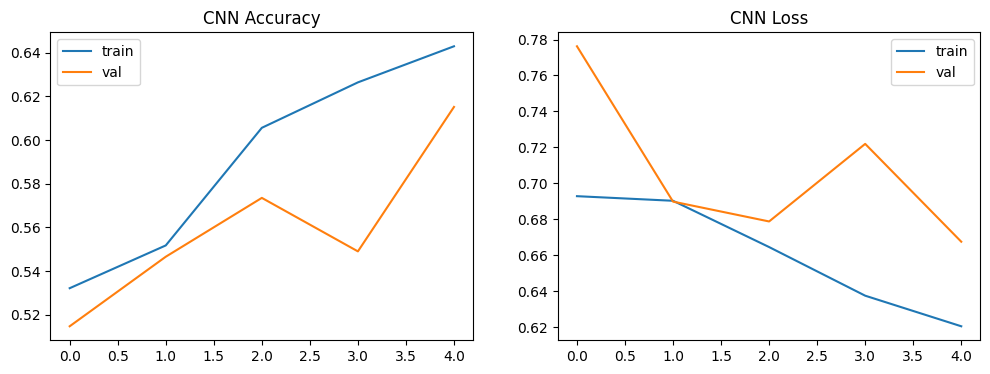

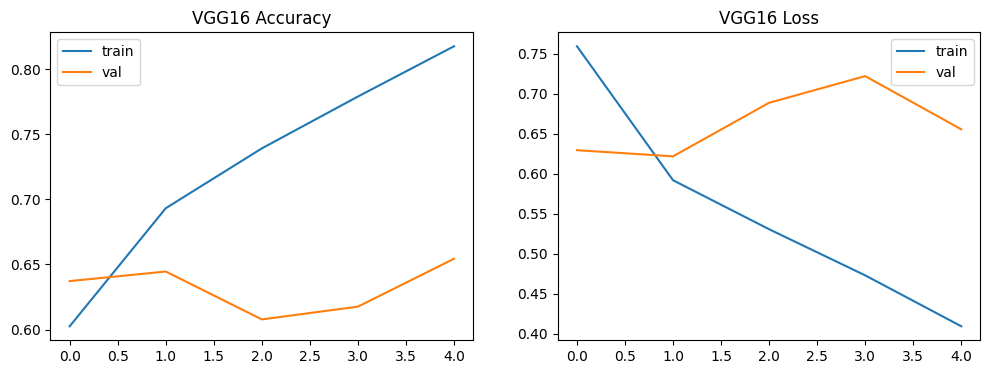

In [7]:
def plot_history(history, title):
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='train')
    plt.plot(history.history['val_accuracy'], label='val')
    plt.title(f'{title} Accuracy')
    plt.legend()
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='train')
    plt.plot(history.history['val_loss'], label='val')
    plt.title(f'{title} Loss')
    plt.legend()
    plt.show()

plot_history(cnn_history, 'CNN')
plot_history(vgg_history, 'VGG16')

## 5. Save Models

In [8]:
os.makedirs('Trained_Models', exist_ok=True)
cnn_model.save('Trained_Models/New_CNN_Model_160.h5')
vgg_model.save('Trained_Models/New_VGG16_Model_160.h5')
print('Models saved successfully.')

Models saved successfully.
